In [1]:
# import pandas as pd 
# import numpy as np 
# import matplotlib.pyplot as plt 
# import requests
# from dotenv import load_dotenv
# load_dotenv()
# import os
# import json 
# import textwrap

In [2]:
# API_KEY = os.environ.get("GRAPH_API_KEY") 
# def run_query(query: str, variables: dict | None = None):
#     payload = {"query": query, "variables": variables or {}}
#     r = requests.post(ENDPOINT, json=payload)
#     r.raise_for_status()
#     data = r.json()
#     if "errors" in data:
#         raise RuntimeError(data["errors"])
#     return data["data"]

## Choose one

In [4]:
# #Curve
# SUBGRAPH_ID = "3fy93eAT56UJsRCEht8iFhfi6wjHWXtZ9dnnbQmvFopF"
# ENDPOINT = f"https://gateway.thegraph.com/api/{API_KEY}/subgraphs/id/{SUBGRAPH_ID}"

## Check the fields 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from dotenv import load_dotenv
import os

# -----------------------------
# Load API key
# -----------------------------

load_dotenv()
API_KEY = os.environ.get("GRAPH_API_KEY")

SUBGRAPH_ID = "3fy93eAT56UJsRCEht8iFhfi6wjHWXtZ9dnnbQmvFopF"
ENDPOINT = f"https://gateway.thegraph.com/api/{API_KEY}/subgraphs/id/{SUBGRAPH_ID}"

POOL_ID = "0xbebc44782c7db0a1a60cb6fe97d0b483032ff1c7"

In [7]:
# -----------------------------
# GraphQL helper
# -----------------------------

def run_query(query, variables=None):

    payload = {"query": query, "variables": variables or {}}

    r = requests.post(ENDPOINT, json=payload)

    r.raise_for_status()

    data = r.json()

    if "errors" in data:
        raise RuntimeError(data["errors"])

    return data["data"]

In [8]:
# -----------------------------
# 1. Get pool balances
# -----------------------------

q_pool = """
query($id: ID!){
  liquidityPool(id: $id){
    id
    name
    inputTokens { symbol decimals }
    inputTokenBalances
  }
}
"""

pool = run_query(q_pool, {"id": POOL_ID})["liquidityPool"]

tokens = pool["inputTokens"]
raw_balances = pool["inputTokenBalances"]

df = pd.DataFrame({
    "symbol": [t["symbol"] for t in tokens],
    "decimals": [int(t["decimals"]) for t in tokens],
    "raw_balance": [int(x) for x in raw_balances],
})

df["balance"] = df["raw_balance"] / (10 ** df["decimals"])
df["share"] = df["balance"] / df["balance"].sum()

print("\nToken balances:")
print(df)


Token balances:
  symbol  decimals                 raw_balance          balance     share
0    DAI        18  65610988179015282419285551  65610988.179015  0.404428
1   USDC         6              66074213323381  66074213.323381  0.407283
2   USDT         6              30546316534359  30546316.534359  0.188288


In [9]:
# -----------------------------
# 2. Compute total liquidity
# -----------------------------

tvl = df["balance"].sum()

print("\nTotal pool liquidity:", tvl)


Total pool liquidity: 162231518.0367553


In [10]:
# -----------------------------
# 3. Get deposits
# -----------------------------

q_dep = """
query($pool: String!) {
  deposits(first: 1000, where: {pool: $pool}) {
    from
    amountUSD
  }
}
"""

deposits = run_query(q_dep, {"pool": POOL_ID})["deposits"]

df_dep = pd.DataFrame({
    "account":[d["from"] for d in deposits],
    "depositUSD":[float(d["amountUSD"]) for d in deposits]
})

dep_sum = df_dep.groupby("account").sum()

RuntimeError: [{'message': 'bad indexers: {0x0fd8fd1dc8162148cb9413062fe6c6b144335dbf: BadResponse(unattestable response: The `first` argument must be between 0 and 1000, but is 10000), 0x2f09092aacd80196fc984908c5a9a7ab3ee4f1ce: BadResponse(unattestable response: The `first` argument must be between 0 and 1000, but is 10000), 0x326c584e0f0eab1f1f83c93cc6ae1acc0feba0bc: BadResponse(unattestable response: The `first` argument must be between 0 and 1000, but is 10000), 0x4e5c87772c29381bcabc58c3f182b6633b5a274a: BadResponse(unattestable response: The `first` argument must be between 0 and 1000, but is 10000), 0x9082f497bdc512d08ffde50d6fce28e72c2addcf: BadResponse(unattestable response: The `first` argument must be between 0 and 1000, but is 10000), 0xedca8740873152ff30a2696add66d1ab41882beb: BadResponse(unattestable response: The `first` argument must be between 0 and 1000, but is 10000), 0xf00f7157fa8fd0420b87956d46058a16b2f23adc: BadResponse(unattestable response: The `first` argument

In [ ]:
# -----------------------------
# 4. Get withdrawals
# -----------------------------

q_wd = """
query($pool: String!) {
  withdraws(first: 1000, where: {pool: $pool}) {
    from
    amountUSD
  }
}
"""

withdraws = run_query(q_wd, {"pool": POOL_ID})["withdraws"]

df_wd = pd.DataFrame({
    "account":[w["from"] for w in withdraws],
    "withdrawUSD":[float(w["amountUSD"]) for w in withdraws]
})

wd_sum = df_wd.groupby("account").sum()


In [ ]:
# -----------------------------
# 5. Compute LP net liquidity
# -----------------------------

net = dep_sum.join(wd_sum, how="outer").fillna(0)

net["net_liquidity"] = net["depositUSD"] - net["withdrawUSD"]

ranking = net["net_liquidity"].sort_values(ascending=False)

print("\nTop LPs:")
print(ranking.head(20))

In [ ]:
# -----------------------------
# 6. Prepare LP dataframe
# -----------------------------

lp_df = ranking.reset_index()
lp_df.columns = ["account", "liquidity"]

top_lp = lp_df.head(10)

top_lp["share"] = top_lp["liquidity"] / lp_df["liquidity"].sum()


In [ ]:
# -----------------------------
# 7. Simulate liquidity curve
# -----------------------------

swap_sizes = np.linspace(0, tvl * 0.2, 200)

price_impact = swap_sizes / tvl

In [ ]:
# -----------------------------
# 8. Plot results
# -----------------------------

fig, axes = plt.subplots(1,2, figsize=(14,5))


# Liquidity curve

axes[0].plot(swap_sizes, price_impact)

axes[0].set_title("Curve Pool Liquidity Curve")

axes[0].set_xlabel("Swap size")

axes[0].set_ylabel("Price impact")



# LP distribution

axes[1].bar(range(len(top_lp)), top_lp["share"])

axes[1].set_title("Top Liquidity Providers")

axes[1].set_xlabel("LP rank")

axes[1].set_ylabel("Share of liquidity")

axes[1].set_xticks(range(len(top_lp)))

axes[1].set_xticklabels(range(1, len(top_lp)+1))

plt.tight_layout()

plt.show()

In [ ]:
# -----------------------------
# 9. Liquidity concentration metric
# -----------------------------

def gini(x):

    x = np.sort(x)

    n = len(x)

    return (np.sum((2*np.arange(1,n+1)-n-1)*x))/(n*np.sum(x))


print("\nLiquidity Gini coefficient:", gini(lp_df["liquidity"].values))


Pool: Curve.fi DAI/USDC/USDT 0xbebc44782c7db0a1a60cb6fe97d0b483032ff1c7

Token balances snapshot:
  symbol  decimals                 raw_balance          balance     share
0    DAI        18  65610988174281872242072435  65610988.174282  0.404428
1   USDC         6              66073767879345  66073767.879345   0.40728
2   USDT         6              30546969862420   30546969.86242  0.188292

Fetched events since t0=1772101749 (last 7 days)
Deposits: 855
Withdraws: 2029
Actual event time range (unix seconds): 1772101751 -> 1772706503

Top actors (by absolute deposit+withdraw USD, last 7d):
                                              depositUSD   withdrawUSD  \
account                                                                  
0x4f062658eaaf2c1ccf8c8e36d6824cdf41167956  1.199322e+06  1.933191e+06   
0x5d0f47b32fdd343bfa74ce221808e2abe4a53827  1.304194e+06  1.304066e+06   
0x5a6a4d54456819380173272a5e8e9b9904bdf41b  1.236874e+06  4.142454e+05   
0x34af8e4fdb0112a0623523ae1a157d4

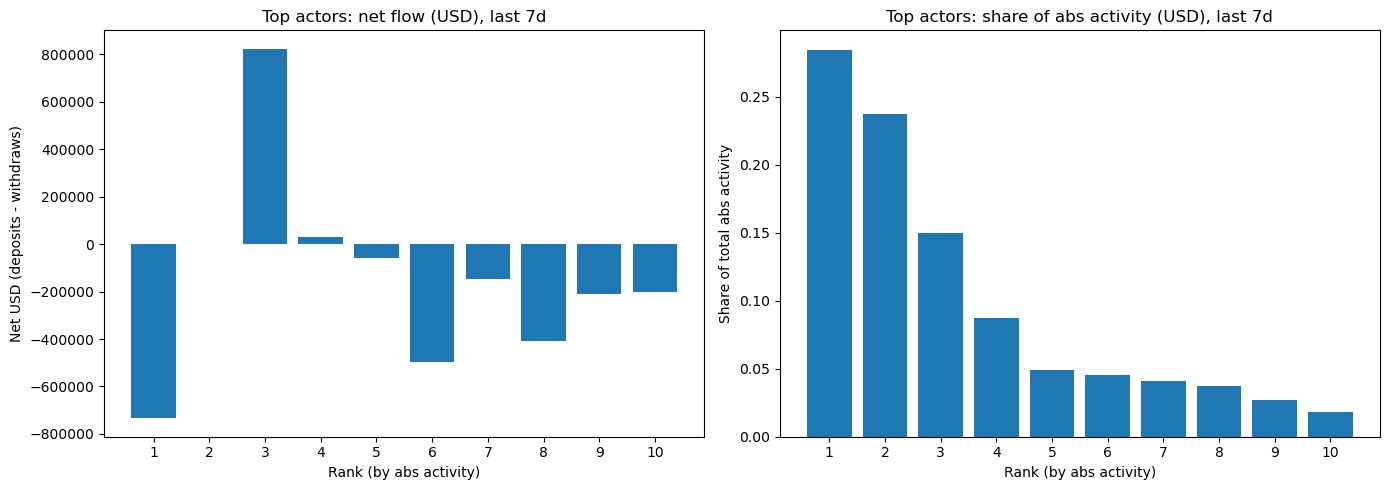


Gini (abs activity USD across all actors, last 7d): 0.9321756446823152


In [22]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# -----------------------------
# Config
# -----------------------------
load_dotenv()
API_KEY = os.environ.get("GRAPH_API_KEY")
if not API_KEY:
    raise RuntimeError("Missing GRAPH_API_KEY in environment (.env).")

SUBGRAPH_ID = "3fy93eAT56UJsRCEht8iFhfi6wjHWXtZ9dnnbQmvFopF"
ENDPOINT = f"https://gateway.thegraph.com/api/{API_KEY}/subgraphs/id/{SUBGRAPH_ID}"

POOL_ID = "0xbebc44782c7db0a1a60cb6fe97d0b483032ff1c7".lower()

DAYS = 7
T0 = int(time.time()) - DAYS * 24 * 3600
PAGE_SIZE = 1000

# -----------------------------
# GraphQL helper
# -----------------------------
def run_query(query, variables=None):
    payload = {"query": query, "variables": variables or {}}
    r = requests.post(ENDPOINT, json=payload, timeout=60)
    r.raise_for_status()
    data = r.json()
    if "errors" in data:
        raise RuntimeError(data["errors"])
    return data["data"]

# -----------------------------
# 1) Pool balances snapshot (same as your original)
# -----------------------------
q_pool = """
query($id: ID!){
  liquidityPool(id: $id){
    id
    name
    inputTokens { symbol decimals }
    inputTokenBalances
  }
}
"""
pool = run_query(q_pool, {"id": POOL_ID})["liquidityPool"]

tokens = pool["inputTokens"]
raw_balances = pool["inputTokenBalances"]

df_bal = pd.DataFrame({
    "symbol": [t["symbol"] for t in tokens],
    "decimals": [int(t["decimals"]) for t in tokens],
    "raw_balance": [int(x) for x in raw_balances],
})
df_bal["balance"] = df_bal["raw_balance"] / (10 ** df_bal["decimals"])
df_bal["share"] = df_bal["balance"] / df_bal["balance"].sum()

print("\nPool:", pool["name"], pool["id"])
print("\nToken balances snapshot:")
print(df_bal)

# -----------------------------
# 2) Last-7d deposits/withdraws with pagination
#    Uses timestamp filtering + ordering for an explicit time window.
# -----------------------------
Q_DEP = """
query($pool: String!, $t0: BigInt!, $skip: Int!, $first: Int!) {
  deposits(
    first: $first,
    skip: $skip,
    orderBy: timestamp,
    orderDirection: asc,
    where: { pool: $pool, timestamp_gte: $t0 }
  ) {
    id
    from
    amountUSD
    timestamp
  }
}
"""

Q_WD = """
query($pool: String!, $t0: BigInt!, $skip: Int!, $first: Int!) {
  withdraws(
    first: $first,
    skip: $skip,
    orderBy: timestamp,
    orderDirection: asc,
    where: { pool: $pool, timestamp_gte: $t0 }
  ) {
    id
    from
    amountUSD
    timestamp
  }
}
"""

def fetch_all(query, key):
    out = []
    skip = 0
    while True:
        data = run_query(query, {"pool": POOL_ID, "t0": T0, "skip": skip, "first": PAGE_SIZE})
        batch = data[key]
        if not batch:
            break
        out.extend(batch)
        skip += PAGE_SIZE
        if len(batch) < PAGE_SIZE:
            break
    return out

deposits = fetch_all(Q_DEP, "deposits")
withdraws = fetch_all(Q_WD, "withdraws")

print(f"\nFetched events since t0={T0} (last {DAYS} days)")
print("Deposits:", len(deposits))
print("Withdraws:", len(withdraws))

df_dep = pd.DataFrame([{
    "account": d["from"].lower(),
    "depositUSD": float(d["amountUSD"]),
    "timestamp": int(d["timestamp"]),
} for d in deposits])

df_wd = pd.DataFrame([{
    "account": w["from"].lower(),
    "withdrawUSD": float(w["amountUSD"]),
    "timestamp": int(w["timestamp"]),
} for w in withdraws])

# Determine actual covered time range from returned data
ts = []
if not df_dep.empty: ts += df_dep["timestamp"].tolist()
if not df_wd.empty: ts += df_wd["timestamp"].tolist()
if not ts:
    raise RuntimeError("No deposits/withdraws in the last week (or timestamp filter field differs).")

print("Actual event time range (unix seconds):", min(ts), "->", max(ts))

# -----------------------------
# 3) Aggregate per account: net flow + absolute activity
# -----------------------------
dep_sum = df_dep.groupby("account", as_index=True)["depositUSD"].sum() if not df_dep.empty else pd.Series(dtype=float)
wd_sum = df_wd.groupby("account", as_index=True)["withdrawUSD"].sum() if not df_wd.empty else pd.Series(dtype=float)

net = pd.concat([dep_sum, wd_sum], axis=1).fillna(0.0)
net.columns = ["depositUSD", "withdrawUSD"]

net["netUSD"] = net["depositUSD"] - net["withdrawUSD"]
net["absActivityUSD"] = net["depositUSD"] + net["withdrawUSD"]

net = net.sort_values("absActivityUSD", ascending=False)

topN = 10
top = net.head(topN).copy()
top["shareAbsActivity"] = top["absActivityUSD"] / net["absActivityUSD"].sum()

print("\nTop actors (by absolute deposit+withdraw USD, last 7d):")
print(top)

# -----------------------------
# 4) Plots
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(top)), top["netUSD"].values)
axes[0].set_title(f"Top actors: net flow (USD), last {DAYS}d")
axes[0].set_xlabel("Rank (by abs activity)")
axes[0].set_ylabel("Net USD (deposits - withdraws)")
axes[0].set_xticks(range(len(top)))
axes[0].set_xticklabels(range(1, len(top) + 1))

axes[1].bar(range(len(top)), top["shareAbsActivity"].values)
axes[1].set_title(f"Top actors: share of abs activity (USD), last {DAYS}d")
axes[1].set_xlabel("Rank (by abs activity)")
axes[1].set_ylabel("Share of total abs activity")
axes[1].set_xticks(range(len(top)))
axes[1].set_xticklabels(range(1, len(top) + 1))

plt.tight_layout()
plt.show()

# -----------------------------
# 5) Concentration metric (Gini on abs activity)
# -----------------------------
def gini(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    x = np.sort(x)
    s = x.sum()
    if s == 0:
        return 0.0
    n = x.size
    return (np.sum((2*np.arange(1, n+1) - n - 1) * x)) / (n * s)

print("\nGini (abs activity USD across all actors, last 7d):", gini(net["absActivityUSD"].values))


Fetched last-30d events since t0=1770114864
Deposits: 3685
Withdraws: 8027
Actual event time range (unix seconds): 1770115955 -> 1772706815


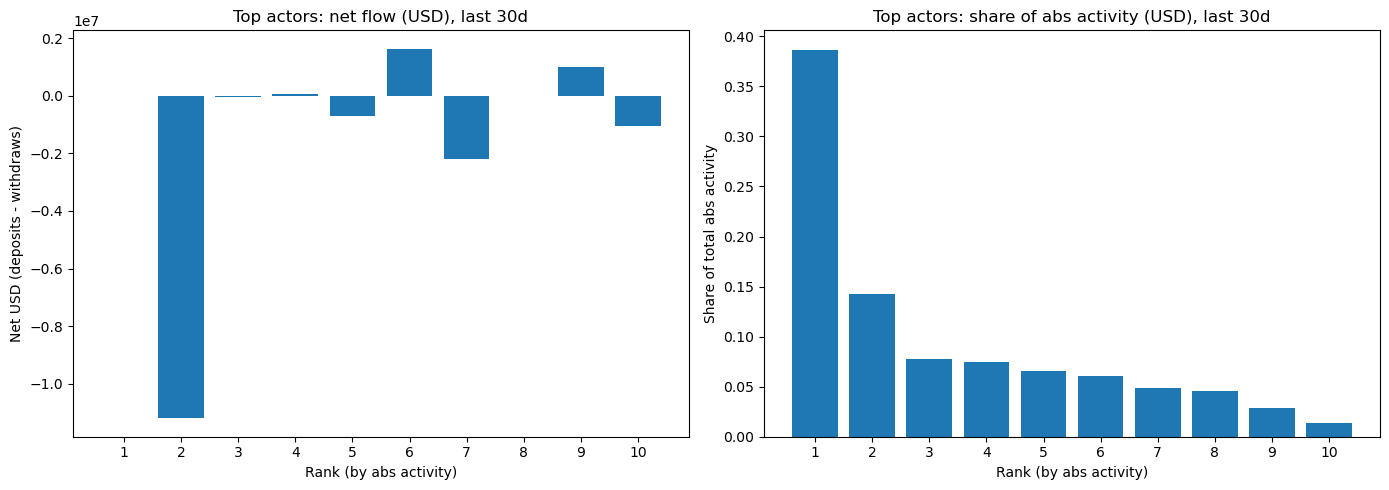

In [24]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.environ.get("GRAPH_API_KEY")
if not API_KEY:
    raise RuntimeError("Missing GRAPH_API_KEY in environment (.env).")

SUBGRAPH_ID = "3fy93eAT56UJsRCEht8iFhfi6wjHWXtZ9dnnbQmvFopF"
ENDPOINT = f"https://gateway.thegraph.com/api/{API_KEY}/subgraphs/id/{SUBGRAPH_ID}"

POOL_ID = "0xbebc44782c7db0a1a60cb6fe97d0b483032ff1c7".lower()

DAYS = 30
T0 = int(time.time()) - DAYS * 24 * 3600
PAGE_SIZE = 1000

def run_query(query, variables=None):
    payload = {"query": query, "variables": variables or {}}
    r = requests.post(ENDPOINT, json=payload, timeout=60)
    r.raise_for_status()
    data = r.json()
    if "errors" in data:
        raise RuntimeError(data["errors"])
    return data["data"]

Q_DEP = """
query($pool: String!, $t0: BigInt!, $lastTs: BigInt!, $first: Int!) {
  deposits(
    first: $first,
    orderBy: timestamp,
    orderDirection: asc,
    where: { pool: $pool, timestamp_gte: $t0, timestamp_gt: $lastTs }
  ) {
    id
    from
    amountUSD
    timestamp
  }
}
"""

Q_WD = """
query($pool: String!, $t0: BigInt!, $lastTs: BigInt!, $first: Int!) {
  withdraws(
    first: $first,
    orderBy: timestamp,
    orderDirection: asc,
    where: { pool: $pool, timestamp_gte: $t0, timestamp_gt: $lastTs }
  ) {
    id
    from
    amountUSD
    timestamp
  }
}
"""

def fetch_all_by_timestamp(query, key):
    out = []
    last_ts = T0 - 1
    while True:
        data = run_query(query, {"pool": POOL_ID, "t0": T0, "lastTs": last_ts, "first": PAGE_SIZE})
        batch = data[key]
        if not batch:
            break
        out.extend(batch)
        last_ts = max(last_ts, max(int(x["timestamp"]) for x in batch))
        if len(batch) < PAGE_SIZE:
            break
    return out

deposits = fetch_all_by_timestamp(Q_DEP, "deposits")
withdraws = fetch_all_by_timestamp(Q_WD, "withdraws")

print(f"Fetched last-{DAYS}d events since t0={T0}")
print("Deposits:", len(deposits))
print("Withdraws:", len(withdraws))

df_dep = pd.DataFrame([{
    "account": d["from"].lower(),
    "depositUSD": float(d["amountUSD"]),
    "timestamp": int(d["timestamp"]),
} for d in deposits])

df_wd = pd.DataFrame([{
    "account": w["from"].lower(),
    "withdrawUSD": float(w["amountUSD"]),
    "timestamp": int(w["timestamp"]),
} for w in withdraws])

ts = []
if not df_dep.empty: ts += df_dep["timestamp"].tolist()
if not df_wd.empty: ts += df_wd["timestamp"].tolist()
if not ts:
    raise RuntimeError("No deposits/withdraws in the last month (or timestamp field differs).")

print("Actual event time range (unix seconds):", min(ts), "->", max(ts))

dep_sum = df_dep.groupby("account", as_index=True)["depositUSD"].sum() if not df_dep.empty else pd.Series(dtype=float)
wd_sum = df_wd.groupby("account", as_index=True)["withdrawUSD"].sum() if not df_wd.empty else pd.Series(dtype=float)

net = pd.concat([dep_sum, wd_sum], axis=1).fillna(0.0)
net.columns = ["depositUSD", "withdrawUSD"]
net["netUSD"] = net["depositUSD"] - net["withdrawUSD"]
net["absActivityUSD"] = net["depositUSD"] + net["withdrawUSD"]
net = net.sort_values("absActivityUSD", ascending=False)

topN = 10
top = net.head(topN).copy()
top["shareAbsActivity"] = top["absActivityUSD"] / net["absActivityUSD"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(top)), top["netUSD"].values)
axes[0].set_title(f"Top actors: net flow (USD), last {DAYS}d")
axes[0].set_xlabel("Rank (by abs activity)")
axes[0].set_ylabel("Net USD (deposits - withdraws)")
axes[0].set_xticks(range(len(top)))
axes[0].set_xticklabels(range(1, len(top) + 1))

axes[1].bar(range(len(top)), top["shareAbsActivity"].values)
axes[1].set_title(f"Top actors: share of abs activity (USD), last {DAYS}d")
axes[1].set_xlabel("Rank (by abs activity)")
axes[1].set_ylabel("Share of total abs activity")
axes[1].set_xticks(range(len(top)))
axes[1].set_xticklabels(range(1, len(top) + 1))

plt.tight_layout()
plt.show()


Fetched last-365d events since t0=1741170946
Deposits: 26907
Withdraws: 37569
Actual event time range (unix seconds): 1741171271 -> 1772706923


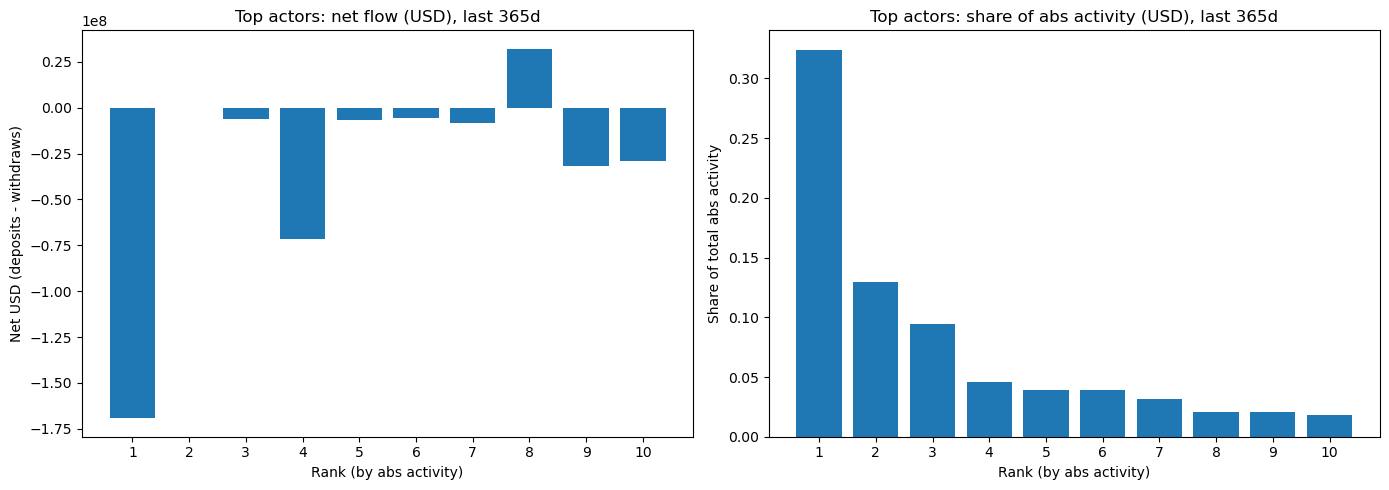

In [28]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.environ.get("GRAPH_API_KEY")
if not API_KEY:
    raise RuntimeError("Missing GRAPH_API_KEY in environment (.env).")

SUBGRAPH_ID = "3fy93eAT56UJsRCEht8iFhfi6wjHWXtZ9dnnbQmvFopF"
ENDPOINT = f"https://gateway.thegraph.com/api/{API_KEY}/subgraphs/id/{SUBGRAPH_ID}"

POOL_ID = "0xbebc44782c7db0a1a60cb6fe97d0b483032ff1c7".lower()

DAYS = 365
T0 = int(time.time()) - DAYS * 24 * 3600
PAGE_SIZE = 1000

def run_query(query, variables=None):
    payload = {"query": query, "variables": variables or {}}
    r = requests.post(ENDPOINT, json=payload, timeout=60)
    r.raise_for_status()
    data = r.json()
    if "errors" in data:
        raise RuntimeError(data["errors"])
    return data["data"]

Q_DEP = """
query($pool: String!, $t0: BigInt!, $lastTs: BigInt!, $lastId: ID!, $first: Int!) {
  deposits(
    first: $first,
    orderBy: timestamp,
    orderDirection: asc,
    where: {
      or: [
        { pool: $pool, timestamp_gte: $t0, timestamp_gt: $lastTs },
        { pool: $pool, timestamp_gte: $t0, timestamp: $lastTs, id_gt: $lastId }
      ]
    }
  ) {
    id
    from
    amountUSD
    timestamp
  }
}
"""

Q_WD = """
query($pool: String!, $t0: BigInt!, $lastTs: BigInt!, $lastId: ID!, $first: Int!) {
  withdraws(
    first: $first,
    orderBy: timestamp,
    orderDirection: asc,
    where: {
      or: [
        { pool: $pool, timestamp_gte: $t0, timestamp_gt: $lastTs },
        { pool: $pool, timestamp_gte: $t0, timestamp: $lastTs, id_gt: $lastId }
      ]
    }
  ) {
    id
    from
    amountUSD
    timestamp
  }
}
"""

def fetch_all_composite_cursor(query, key):
    out = []
    last_ts = T0 - 1
    last_id = ""
    while True:
        data = run_query(query, {
            "pool": POOL_ID,
            "t0": T0,
            "lastTs": int(last_ts),
            "lastId": last_id,
            "first": PAGE_SIZE
        })
        batch = data[key]
        if not batch:
            break

        out.extend(batch)
        last_ts = int(batch[-1]["timestamp"])
        last_id = batch[-1]["id"]

        if len(batch) < PAGE_SIZE:
            break

    return out

deposits = fetch_all_composite_cursor(Q_DEP, "deposits")
withdraws = fetch_all_composite_cursor(Q_WD, "withdraws")

print(f"Fetched last-{DAYS}d events since t0={T0}")
print("Deposits:", len(deposits))
print("Withdraws:", len(withdraws))

df_dep = pd.DataFrame([{
    "account": d["from"].lower(),
    "depositUSD": float(d["amountUSD"]),
    "timestamp": int(d["timestamp"]),
} for d in deposits])

df_wd = pd.DataFrame([{
    "account": w["from"].lower(),
    "withdrawUSD": float(w["amountUSD"]),
    "timestamp": int(w["timestamp"]),
} for w in withdraws])

ts = []
if not df_dep.empty: ts += df_dep["timestamp"].tolist()
if not df_wd.empty: ts += df_wd["timestamp"].tolist()
if not ts:
    raise RuntimeError("No deposits/withdraws in the last year (or timestamp filter field differs).")

print("Actual event time range (unix seconds):", min(ts), "->", max(ts))

dep_sum = df_dep.groupby("account", as_index=True)["depositUSD"].sum() if not df_dep.empty else pd.Series(dtype=float)
wd_sum = df_wd.groupby("account", as_index=True)["withdrawUSD"].sum() if not df_wd.empty else pd.Series(dtype=float)

net = pd.concat([dep_sum, wd_sum], axis=1).fillna(0.0)
net.columns = ["depositUSD", "withdrawUSD"]
net["netUSD"] = net["depositUSD"] - net["withdrawUSD"]
net["absActivityUSD"] = net["depositUSD"] + net["withdrawUSD"]
net = net.sort_values("absActivityUSD", ascending=False)

topN = 10
top = net.head(topN).copy()
top["shareAbsActivity"] = top["absActivityUSD"] / net["absActivityUSD"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(top)), top["netUSD"].values)
axes[0].set_title(f"Top actors: net flow (USD), last {DAYS}d")
axes[0].set_xlabel("Rank (by abs activity)")
axes[0].set_ylabel("Net USD (deposits - withdraws)")
axes[0].set_xticks(range(len(top)))
axes[0].set_xticklabels(range(1, len(top) + 1))

axes[1].bar(range(len(top)), top["shareAbsActivity"].values)
axes[1].set_title(f"Top actors: share of abs activity (USD), last {DAYS}d")
axes[1].set_xlabel("Rank (by abs activity)")
axes[1].set_ylabel("Share of total abs activity")
axes[1].set_xticks(range(len(top)))
axes[1].set_xticklabels(range(1, len(top) + 1))

plt.tight_layout()
plt.show()


In [30]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# For GIF
import imageio.v2 as imageio

load_dotenv()
API_KEY = os.environ.get("GRAPH_API_KEY")
if not API_KEY:
    raise RuntimeError("Missing GRAPH_API_KEY in environment (.env).")

SUBGRAPH_ID = "3fy93eAT56UJsRCEht8iFhfi6wjHWXtZ9dnnbQmvFopF"
ENDPOINT = f"https://gateway.thegraph.com/api/{API_KEY}/subgraphs/id/{SUBGRAPH_ID}"

POOL_ID = "0xbebc44782c7db0a1a60cb6fe97d0b483032ff1c7".lower()

DAYS = 30
T0 = int(time.time()) - DAYS * 24 * 3600
PAGE_SIZE = 1000
TOPN = 10

OUTDIR = "frames_last30d"
os.makedirs(OUTDIR, exist_ok=True)

def run_query(query, variables=None):
    payload = {"query": query, "variables": variables or {}}
    r = requests.post(ENDPOINT, json=payload, timeout=60)
    r.raise_for_status()
    data = r.json()
    if "errors" in data:
        raise RuntimeError(data["errors"])
    return data["data"]

Q_DEP = """
query($pool: String!, $t0: BigInt!, $lastTs: BigInt!, $lastId: ID!, $first: Int!) {
  deposits(
    first: $first,
    orderBy: timestamp,
    orderDirection: asc,
    where: {
      or: [
        { pool: $pool, timestamp_gte: $t0, timestamp_gt: $lastTs },
        { pool: $pool, timestamp_gte: $t0, timestamp: $lastTs, id_gt: $lastId }
      ]
    }
  ) {
    id
    from
    amountUSD
    timestamp
  }
}
"""

Q_WD = """
query($pool: String!, $t0: BigInt!, $lastTs: BigInt!, $lastId: ID!, $first: Int!) {
  withdraws(
    first: $first,
    orderBy: timestamp,
    orderDirection: asc,
    where: {
      or: [
        { pool: $pool, timestamp_gte: $t0, timestamp_gt: $lastTs },
        { pool: $pool, timestamp_gte: $t0, timestamp: $lastTs, id_gt: $lastId }
      ]
    }
  ) {
    id
    from
    amountUSD
    timestamp
  }
}
"""

def fetch_all_composite_cursor(query, key):
    out = []
    last_ts = T0 - 1
    last_id = ""
    while True:
        data = run_query(query, {
            "pool": POOL_ID,
            "t0": T0,
            "lastTs": int(last_ts),
            "lastId": last_id,
            "first": PAGE_SIZE
        })
        batch = data[key]
        if not batch:
            break
        out.extend(batch)
        last_ts = int(batch[-1]["timestamp"])
        last_id = batch[-1]["id"]
        if len(batch) < PAGE_SIZE:
            break
    return out

print("Fetching last 30d deposits/withdraws...")
deposits = fetch_all_composite_cursor(Q_DEP, "deposits")
withdraws = fetch_all_composite_cursor(Q_WD, "withdraws")
print("Deposits:", len(deposits), "Withdraws:", len(withdraws))

df_dep = pd.DataFrame([{
    "account": d["from"].lower(),
    "depositUSD": float(d["amountUSD"]),
    "ts": int(d["timestamp"]),
} for d in deposits])

df_wd = pd.DataFrame([{
    "account": w["from"].lower(),
    "withdrawUSD": float(w["amountUSD"]),
    "ts": int(w["timestamp"]),
} for w in withdraws])

if df_dep.empty and df_wd.empty:
    raise RuntimeError("No events in last 30 days.")

events_ts = pd.concat([
    df_dep[["ts"]].assign(kind="dep"),
    df_wd[["ts"]].assign(kind="wd")
], ignore_index=True)

tmin, tmax = int(events_ts["ts"].min()), int(events_ts["ts"].max())
start_day = pd.to_datetime(T0, unit="s", utc=True).floor("D")
end_day   = pd.to_datetime(tmax, unit="s", utc=True).floor("D")

# Assign each event to a UTC day
if not df_dep.empty:
    df_dep["day"] = pd.to_datetime(df_dep["ts"], unit="s", utc=True).dt.floor("D")
if not df_wd.empty:
    df_wd["day"] = pd.to_datetime(df_wd["ts"], unit="s", utc=True).dt.floor("D")

days = pd.date_range(start_day, end_day, freq="D", tz="UTC")

frame_files = []

def make_top_table(day):
    dep_day = df_dep[df_dep["day"] == day] if not df_dep.empty else df_dep
    wd_day  = df_wd[df_wd["day"] == day] if not df_wd.empty else df_wd

    dep_sum = dep_day.groupby("account")["depositUSD"].sum() if not dep_day.empty else pd.Series(dtype=float)
    wd_sum  = wd_day.groupby("account")["withdrawUSD"].sum() if not wd_day.empty else pd.Series(dtype=float)

    net = pd.concat([dep_sum, wd_sum], axis=1).fillna(0.0)
    if net.empty:
        return None

    net.columns = ["depositUSD", "withdrawUSD"]
    net["netUSD"] = net["depositUSD"] - net["withdrawUSD"]
    net["absActivityUSD"] = net["depositUSD"] + net["withdrawUSD"]

    # rank by abs activity
    net = net.sort_values("absActivityUSD", ascending=False)
    top = net.head(TOPN).copy()

    denom = net["absActivityUSD"].sum()
    top["shareAbsActivity"] = (top["absActivityUSD"] / denom) if denom > 0 else 0.0
    return top

for i, day in enumerate(days):
    top = make_top_table(day)
    day_str = day.strftime("%Y-%m-%d")
    fname = os.path.join(OUTDIR, f"frame_{i:03d}_{day_str}.png")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if top is None or (top["absActivityUSD"].sum() == 0):
        axes[0].set_title(f"Net flow (USD) | {day_str} (no events)")
        axes[1].set_title(f"Abs activity share | {day_str} (no events)")
        for ax in axes:
            ax.set_axis_off()
    else:
        axes[0].bar(range(len(top)), top["netUSD"].values)
        axes[0].set_title(f"Top actors: net flow (USD) | {day_str}")
        axes[0].set_xlabel("Rank")
        axes[0].set_ylabel("Net USD")
        axes[0].set_xticks(range(len(top)))
        axes[0].set_xticklabels(range(1, len(top) + 1))

        axes[1].bar(range(len(top)), top["shareAbsActivity"].values)
        axes[1].set_title(f"Top actors: abs activity share | {day_str}")
        axes[1].set_xlabel("Rank")
        axes[1].set_ylabel("Share")
        axes[1].set_xticks(range(len(top)))
        axes[1].set_xticklabels(range(1, len(top) + 1))
        axes[1].set_ylim(0, max(0.05, float(top["shareAbsActivity"].max()) * 1.15))

    plt.tight_layout()
    plt.savefig(fname, dpi=140)
    plt.close(fig)
    frame_files.append(fname)

gif_path = "curve_3pool_top_actors_last30d_daily.gif"
with imageio.get_writer(gif_path, mode="I", duration=0.6) as writer:
    for f in frame_files:
        writer.append_data(imageio.imread(f))

print("Saved GIF:", gif_path)
print("Frames in:", OUTDIR)


Fetching last 30d deposits/withdraws...
Deposits: 3688 Withdraws: 8027
Saved GIF: curve_3pool_top_actors_last30d_daily.gif
Frames in: frames_last30d
